# Function to Figure out Vulcan Grid Spacing Automatically

In [1]:
# Print statement just to make sure conda is using the version of POSEIDON tied with Vulcan

import POSEIDON
POSEIDON.__file__

'/Users/elijahmullens/Desktop/POSEIDON-VULCAN/POSEIDON/__init__.py'

Define star and planet for planet you are computing spectra for

In [2]:
from POSEIDON.core import create_star, create_planet
from POSEIDON.constants import R_Sun, R_J, M_J

#***** Define stellar properties *****#

R_s = 0.9*R_Sun   # Stellar radius (m)
T_s = 5400          # Stellar effective temperature (K)
Met_s = 0.01        # Stellar metallicity [log10(Fe/H_star / Fe/H_solar)]
log_g_s = 4.45        # Stellar log surface gravity (log10(cm/s^2) by convention)

# Create the stellar object
star = create_star(R_s, T_s, log_g_s, Met_s)

#***** Define planet properties *****#

planet_name = 'WASP-39 b'  # Planet name used for plots, output files etc.

R_p = 1.27*R_J     # Planetary radius (m)
M_p = 0.28*M_J       # Planetary mass (kg)
T_eq = 1116           # Equilibrium temperature (K)

# Create the planet object
planet = create_planet(planet_name, R_p, mass = M_p, T_eq = T_eq)

Create the Vulcan Grid model. 

Note that in this notebook I only use a subset of the species for speed, but in reality you should use 'all' when figuring out the grid spacing

In [3]:
from POSEIDON.core import define_model
import numpy as np

#***** Define models *****#

#model_name_1 = 'eq_chemistry_full'   
model_name_2 = 'eq_chemistry_subset'

bulk_species = ['H2', 'He']      # H2 + He comprises the bulk atmosphere

#param_species_full = ['all']
param_species_subset = ['H','H2O', 'CH4', 'CO', 'CO2']

model_subset = define_model(model_name_2, bulk_species, param_species_subset, 
                            X_profile = 'chem_diseq',
                            diseq_grid_name = "VULCAN_Grid1.1",
                            )

In [4]:
# Pringint out model params to ensure they go to the right place when making the atmosphere object

print(model_subset['X_param_names'])
print(model_subset['PT_param_names'])

['C_O' 'log_met']
['log_kappa_IR' 'T_equ']


Load in the grid you are wanting to check the spacing of

In [5]:
from POSEIDON.chemistry import load_vulcan_chemistry_grid

# Load the subset chemical equilibrium grid
chemistry_grid_subset = load_vulcan_chemistry_grid(param_species_subset, grid = "VULCAN_Grid1.1")

Reading in database for VULCAN model...


### Load Opacities

Here we take the opacities from 0.2-13 um, which is the entire wavelength range we would ever care about. 

R = 5000 for speed, but in reality it should be 10k or 15k

In [6]:
from POSEIDON.core import wl_grid_constant_R, read_opacities

#***** Wavelength grid *****#
 
wl_min = 0.2       # Minimum wavelength (um)
wl_max = 13       # Maximum wavelength (um)
R = 5000          # Spectral resolution of grid

wl = wl_grid_constant_R(wl_min, wl_max, R)

#***** Read opacity data *****#

opacity_treatment = 'opacity_sampling'

# First, specify limits of the fine temperature and pressure grids for the 
# pre-interpolation of cross sections. These fine grids should cover a
# wide range of possible temperatures and pressures for the model atmosphere.

# Define fine temperature grid (K)
T_fine_min = 100     # 400 K lower limit suffices for a typical hot Jupiter
T_fine_max = 10000    # 2000 K upper limit suffices for a typical hot Jupiter
T_fine_step = 20     # 10 K steps are a good tradeoff between accuracy and RAM

T_fine = np.arange(T_fine_min, (T_fine_max + T_fine_step), T_fine_step)

# Define fine pressure grid (log10(P/bar))
log_P_fine_min = -6.0   # 1 ubar is the lowest pressure in the opacity database
log_P_fine_max = 2.0    # 100 bar is the highest pressure in the opacity database
log_P_fine_step = 0.2   # 0.2 dex steps are a good tradeoff between accuracy and RAM

log_P_fine = np.arange(log_P_fine_min, (log_P_fine_max + log_P_fine_step), 
                       log_P_fine_step)

# Pre-interpolate the sampled opacities for both models (the subset will be faster!)
opac_subset = read_opacities(model_subset, wl, opacity_treatment, T_fine, log_P_fine)

Reading in cross sections in opacity sampling mode...
H2-H2 done
H2-He done
H2-H done
H2-CH4 done
CO2-H2 done
CO2-CO2 done
CO2-CH4 done
H2O done
CH4 done
CO done
CO2 done
Opacity pre-interpolation complete.


# 4D Grid Spacing Function 

In [7]:
# Original Grid Parameters
# With each iteration, this list will need to be updated
# to reflect the new grid spacing 

kappa_IR = [-3.5,-3.25,-3.0,-2.75,-2.50]
Teq = [700,800,900,1000,1100]
C_O = [0.2,1,1.5,2]
lot_met = [-1,0,1,2,3,4]

Function that takes in the grid params, makes atmosphere object, and then makes the spectrum. 

Takes in wl_min and wl_max as parameters in case user doesn't want to compute differences across entire wavelength range but instead wants to focus on something like the SO2 band. 

In [14]:
from POSEIDON.core import make_atmosphere
from POSEIDON.core import compute_spectrum

# Finds nearest index in an array 
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx

def model(wl, log_kappa_IR, Teq, C_to_O, log_Met,
          wl_min, wl_max):

    # Specify the pressure grid of the atmosphere
    # With min and max pressure of Vulcan Grid 
    
    P_min = 1.0e-6    # 0.1 ubar
    P_max = 10       # 100 bar
    N_layers = 100    # 100 layers

    # We'll space the layers uniformly in log-pressure
    P = np.logspace(np.log10(P_max), np.log10(P_min), N_layers)

    # Specify the reference pressure and radius
    P_ref = 10.0   # Reference pressure (bar)
    R_p_ref = R_p  # Radius at reference pressure

    # Provide a specific set of model parameters for the atmosphere 
    PT_params = np.array([log_kappa_IR,Teq])              # T (K)
    X_params = np.array([C_to_O, log_Met])    # The parameters are just C/O and log(Met) for an equilibrium model

    # Generate two atmospheres: one with the full equilibrium grid and one with the subset
    atmosphere_subset = make_atmosphere(planet, model_subset, P, P_ref, R_p_ref, PT_params, 
                                        X_params, chemistry_grid = chemistry_grid_subset,
                                        use_conv_flag= False
                                        )
    
    spectrum_subset = compute_spectrum(planet, star, model_subset, atmosphere_subset, 
                                   opac_subset, wl, spectrum_type = 'transmission')
    
    if wl_min != np.min(wl) or wl_max != np.max(wl):

        wl_min_index = find_nearest(wl, wl_min)
        wl_max_index = find_nearest(wl, wl_max)

        spectrum_subset = spectrum_subset[wl_min_index:wl_max_index]
    
    return spectrum_subset

Function that loops through each parameter and generates the spectrum, adding it to the grid array. 

With each new parameter added to the grid, you just need to add a new 'n'.

Here

nx = log_kappa_IR

ny = Teq

nz = C_to_O

nm = log_Met

In [21]:
# Calculate a grid
def calcgrid(wl, xs, ys, zs, ms,
             wl_min = 0.2, wl_max = 13):
    
    nx = len(xs)
    ny = len(ys)
    nz = len(zs)
    nm = len(ms)

    if wl_min != np.min(wl) or wl_max != np.max(wl):

        wl_min_index = find_nearest(wl, wl_min)
        wl_max_index = find_nearest(wl, wl_max)
    
        nwl = len(wl[wl_min_index:wl_max_index])
    
    else:
         nwl = len(wl)
    
    grid = np.zeros((nx, ny, nz, nm, nwl))

    for ix, x in enumerate(xs):
        for iy, y in enumerate(ys):
            for iz, z in enumerate(zs):
                    for im, m in enumerate(ms):
                        grid[ix, iy, iz, im] = model(wl, x, y, z, m, wl_min, wl_max)

    return grid

Helper function that just prints out the new combinations to run the grid at

In [32]:
def find_new_combos(log_kappa_IR_array_og,Teq_array_og, 
               C_to_O_array_og,log_Met_array_og,
               new_axes):
    

    old_combos = []
    new_combos_all = []

    for ix, x in enumerate(log_kappa_IR_array_og):
        for iy, y in enumerate(Teq_array_og):
            for iz, z in enumerate(C_to_O_array_og):
                    for im, m in enumerate(log_Met_array_og):
                         old_combos.append([x,y,z,m])

    for ix, x in enumerate(new_axes[0]):
        for iy, y in enumerate(new_axes[1]):
            for iz, z in enumerate(new_axes[2]):
                    for im, m in enumerate(new_axes[3]):
                         new_combos_all.append([x,y,z,m])

    new_combos = [element for element in new_combos_all if element not in old_combos]

    return new_combos

Function that actually loops through the grid of spectra, takes differences between each axis, and creates new spacing, keeping everything rectangular.

In [17]:
# grid = array of spectra generated by calcgrid
# axes_og = array of variables the grid is made with 
# tolerance = max tolerance for differences between spectra 

def generate_new_grid_spacing(grid, axes_og, tolerance):

    # Loop over variables that remake axis 
    nvar = len(axes_og)

    new_axes = axes_og.copy()

    # Absolute tolerance (models must differ by less than this everywhere)
    tol = tolerance

    print("Initial grid dimensions: {}".format(grid.shape))

    # making the og arrays 
    log_kappa_IR_array_og = axes_og[0]
    Teq_array_og = axes_og[1]
    C_to_O_array_og = axes_og[2]
    log_Met_array_og = axes_og[3]

    donebools = np.ones(len(axes_og), dtype=bool)

    # Loop over variable axes
    for i in range(nvar):
        # Calculate differences between slices 
        diffs = np.diff(grid, axis=i)
        # List of where we need to insert new values
        insertind = []
        # Loop over the slices for this axis
        for j in range(diffs.shape[i]):
            # Slice the differences along the dimension corresponding
            # to this axis. Trust me.
            # Will do!
            indx = [slice(None)] * diffs.ndim
            indx[i] = j
            indx = tuple(indx)
            # Check if the maximum difference of this slice is below
            # the tolerance and, if not, flag this index for insertion
            # a new value later (j+1 because np.insert puts the value
            # *before* the index) and note that we need to recheck
            # this axis.
            if np.max(np.abs(diffs[indx])) > tol:
                insertind.append(j+1)
                donebools[i] = False

        insertind = np.array(insertind)

        # Insert new values as needed. Use the midpoints.
        if len(insertind) != 0:
            insertval = (new_axes[i][insertind-1] + new_axes[i][insertind]) / 2
            new_axes[i] = np.insert(new_axes[i], insertind, insertval)

    # Printing old and new grid 

    print()
    print("Old Kappa Ir: ", log_kappa_IR_array_og)
    print("New Kappa_IR: {}".format(new_axes[0]))
    print()
    print("Old T equ ", Teq_array_og)
    print("New T equ: {}".format(new_axes[1]))
    print()
    print("Old C_to_O: ", C_to_O_array_og)
    print("New C_to_O: {}".format(new_axes[2]))
    print()
    print("Old log Met ", log_Met_array_og)
    print("New log Met: {}".format(new_axes[3]))

    # Figure out new combinations to run grid at 
    new_combos = find_new_combos(log_kappa_IR_array_og,Teq_array_og, 
                                 C_to_O_array_og,log_Met_array_og,
                                 new_axes)

    return new_axes, new_combos

Cell Code to actually run the functions above

In [22]:
# Initial grid
# Need to be arrays for code to work 
log_kappa_IR_array = np.array([-3.5,-3.25,-3.0,-2.75,-2.50])
Teq_array = np.array([700,800,900,1000,1100])
C_to_O_array = np.array([0.21,1,1.5,2])
log_Met_array = np.array([-1.0,0.0,1.0,2.0,3.0,4.0])

# Redefining things a bit to be more generic 
nx = len(log_kappa_IR_array)
ny = len(Teq_array)
nz = len(C_to_O_array)
nm = len(log_Met_array)

xs = log_kappa_IR_array
ys = Teq_array
zs = C_to_O_array
ms = log_Met_array

axes = [xs, ys,zs, ms]

# Make the grid of spectra (full wavelength range)
grid = calcgrid(wl, axes[0], axes[1], axes[2], axes[3])

# Make the grid of spectra (just SO2 and CO2 band)
grid_so2_co2 = calcgrid(wl, axes[0], axes[1], axes[2], axes[3],
                        wl_min = 3.8, wl_max = 4.8)

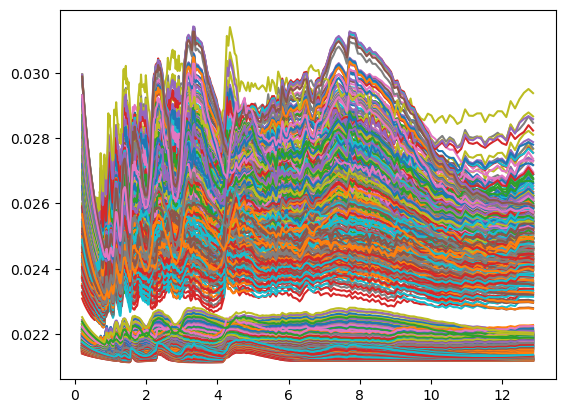

In [23]:
# Just plotting the entire grid for fun 

import matplotlib.pyplot as plt 
from POSEIDON.utility import bin_spectrum

for ix, x in enumerate(xs):
    for iy, y in enumerate(ys):
        for iz, z in enumerate(zs):
                for im, m in enumerate(ms):
                    wl_binned, spectra_binned, err_binned = bin_spectrum(wl, grid[ix, iy, iz, im], 100, err_data = [])
                    plt.plot(wl_binned,spectra_binned)

plt.show()

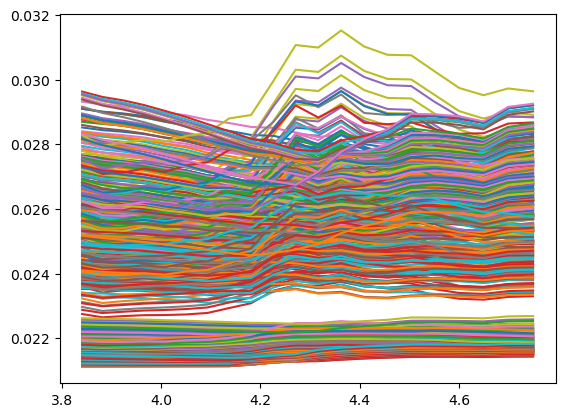

In [24]:
# Just plotting the entire grid for fun 

import matplotlib.pyplot as plt 
from POSEIDON.utility import bin_spectrum

wl_min_index = find_nearest(wl, 3.8)
wl_max_index = find_nearest(wl, 4.8)

wl_subset = wl[wl_min_index:wl_max_index]

for ix, x in enumerate(xs):
    for iy, y in enumerate(ys):
        for iz, z in enumerate(zs):
                for im, m in enumerate(ms):
                    wl_binned, spectra_binned, err_binned = bin_spectrum(wl_subset, grid_so2_co2[ix, iy, iz, im], 100, err_data = [])
                    plt.plot(wl_binned,spectra_binned)

plt.show()

In [37]:
# I think this is a reasonable tolerance based off data and plots above

tolerance = 0.005

new_axes_full_wl, new_combos_full_wl = generate_new_grid_spacing(grid, axes, tolerance)

print()
print('Number of new combos to run Vulcan at: ')
print(len(new_combos_full_wl))

Initial grid dimensions: (5, 5, 4, 6, 20872)

Old Kappa Ir:  [-3.5  -3.25 -3.   -2.75 -2.5 ]
New Kappa_IR: [-3.5   -3.375 -3.25  -3.125 -3.    -2.875 -2.75  -2.625 -2.5  ]

Old T equ  [ 700  800  900 1000 1100]
New T equ: [ 700  800  900  950 1000 1050 1100]

Old C_to_O:  [0.21 1.   1.5  2.  ]
New C_to_O: [0.21  0.605 1.    1.25  1.5   2.   ]

Old log Met  [-1.  0.  1.  2.  3.  4.]
New log Met: [-1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3.   3.5  4. ]

Number of new combos to run Vulcan at: 
3558


In [38]:
# I think this is a reasonable tolerance based off data and plots above

tolerance = 0.005

new_axes_full_wl, new_combos_full_wl = generate_new_grid_spacing(grid_so2_co2, axes, tolerance)

print()
print('Number of new combos to run Vulcan at: ')
print(len(new_combos_full_wl))

Initial grid dimensions: (5, 5, 4, 6, 1168)

Old Kappa Ir:  [-3.5  -3.25 -3.   -2.75 -2.5 ]
New Kappa_IR: [-3.5   -3.375 -3.25  -3.    -2.75  -2.625 -2.5  ]

Old T equ  [ 700  800  900 1000 1100]
New T equ: [ 700  800  900  950 1000 1050 1100]

Old C_to_O:  [0.21 1.   1.5  2.  ]
New C_to_O: [0.21  0.605 1.    1.25  1.5   2.   ]

Old log Met  [-1.  0.  1.  2.  3.  4.]
New log Met: [-1.  -0.5  0.   0.5  1.   1.5  2.   2.5  3.   3.5  4. ]

Number of new combos to run Vulcan at: 
2634
